In [1]:
!pip install -q transformers torch torchvision pillow requests sentence-transformers

Loaded: car_red, size: (400, 267)
Loaded: car_blue, size: (400, 267)
Loaded: dog_1, size: (400, 641)
Loaded: dog_2, size: (400, 600)
Loaded: room_1, size: (400, 267)
Loaded: room_2, size: (400, 267)


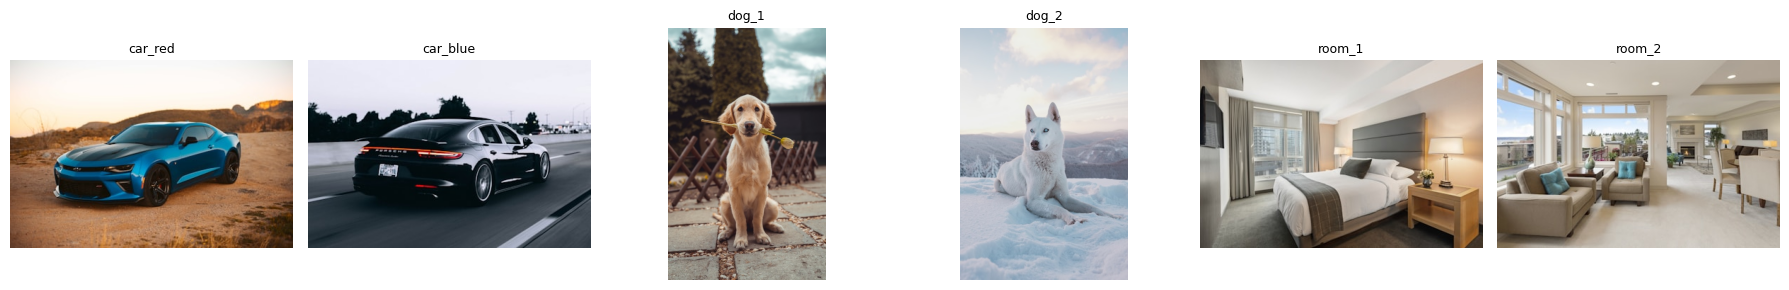

In [2]:
import requests
from PIL import Image
from io import BytesIO

# A small pool of images across a few categories - enough for retrieval to find "similar but different" matches
image_urls = {
    "car_red": "https://images.unsplash.com/photo-1552519507-da3b142c6e3d",
    "car_blue": "https://images.unsplash.com/photo-1503376780353-7e6692767b70",
    "dog_1": "https://images.unsplash.com/photo-1552053831-71594a27632d",
    "dog_2": "https://images.unsplash.com/photo-1547407139-3c921a66005c",
    "room_1": "https://images.unsplash.com/photo-1631049307264-da0ec9d70304",
    "room_2": "https://images.unsplash.com/photo-1560448204-e02f11c3d0e2",
}

images = {}
for name, url in image_urls.items():
    response = requests.get(url + "?w=400")
    img = Image.open(BytesIO(response.content)).convert("RGB")
    images[name] = img
    print(f"Loaded: {name}, size: {img.size}")

# Quick visual check
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, len(images), figsize=(18, 3))
for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img)
    ax.set_title(name, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [3]:
from transformers import BlipProcessor, BlipForConditionalGeneration
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(DEVICE)
blip_model.eval()

def generate_caption(image: Image.Image) -> str:
    """Generate a caption for an image - this acts as our y_w (chosen response)."""
    inputs = blip_processor(images=image, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        output = blip_model.generate(**inputs, max_new_tokens=30)
    caption = blip_processor.decode(output[0], skip_special_tokens=True)
    return caption

# Generate chosen responses for all images
chosen_responses = {}
for name, img in images.items():
    caption = generate_caption(img)
    chosen_responses[name] = caption
    print(f"{name}: {caption}")

Using device: cpu


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

car_red: a blue chevrolet camaro on a dirt road
car_blue: a black porsche driving down a highway
dog_1: a puppy with a stick in its mouth
dog_2: a white dog laying in the snow
room_1: a hotel room with a bed and television
room_2: a living room with a large window and a couch


In [4]:
import re

# Simple heuristic masking: mask out nouns and color/attribute words
# This is our simplified stand-in for the paper's GPT-4o-mini-based "Strategic Masking" prompt
MASK_TOKEN = "[MASK]"

# Common attribute/color words + we'll also mask nouns using simple POS-like heuristics
attribute_words = {"red", "blue", "green", "yellow", "black", "white", "brown", "large", "small",
                    "young", "old", "wooden", "grassy", "furry"}

def strategic_mask(caption: str) -> tuple[str, list[str]]:
    """
    Simplified masking: replace attribute/color words and the first noun-like word
    (heuristic: word after 'a' or 'an') with [MASK].
    Returns the masked caption and the list of masked-out original words (for reference).
    """
    words = caption.split()
    masked_words = []
    masked = []

    for i, word in enumerate(words):
        clean_word = word.strip(".,").lower()
        # Mask known attribute words
        if clean_word in attribute_words:
            masked_words.append(word)
            masked.append(MASK_TOKEN)
        # Mask the word right after "a"/"an" (common noun pattern)
        elif i > 0 and words[i-1].lower() in ("a", "an") and clean_word not in ("a", "an"):
            masked_words.append(word)
            masked.append(MASK_TOKEN)
        else:
            masked.append(word)

    masked_caption = " ".join(masked)
    return masked_caption, masked_words

# Apply masking to all chosen responses
masked_responses = {}
for name, caption in chosen_responses.items():
    masked_caption, removed_words = strategic_mask(caption)
    masked_responses[name] = masked_caption
    print(f"{name}:")
    print(f"  Original: {caption}")
    print(f"  Masked:   {masked_caption}")
    print(f"  Removed:  {removed_words}\n")

car_red:
  Original: a blue chevrolet camaro on a dirt road
  Masked:   a [MASK] chevrolet camaro on a [MASK] road
  Removed:  ['blue', 'dirt']

car_blue:
  Original: a black porsche driving down a highway
  Masked:   a [MASK] porsche driving down a [MASK]
  Removed:  ['black', 'highway']

dog_1:
  Original: a puppy with a stick in its mouth
  Masked:   a [MASK] with a [MASK] in its mouth
  Removed:  ['puppy', 'stick']

dog_2:
  Original: a white dog laying in the snow
  Masked:   a [MASK] dog laying in the snow
  Removed:  ['white']

room_1:
  Original: a hotel room with a bed and television
  Masked:   a [MASK] room with a [MASK] and television
  Removed:  ['hotel', 'bed']

room_2:
  Original: a living room with a large window and a couch
  Masked:   a [MASK] room with a [MASK] window and a [MASK]
  Removed:  ['living', 'large', 'couch']



In [5]:
from transformers import CLIPModel, CLIPProcessor

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

def get_clip_embedding(image: Image.Image):
    inputs = clip_processor(images=image, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = clip_model.get_image_features(**inputs)
        features = outputs.pooler_output if hasattr(outputs, "pooler_output") else outputs
    features = features / features.norm(p=2, dim=-1, keepdim=True)
    return features.cpu().numpy().flatten()

# Embed all images
image_names = list(images.keys())
embeddings = {name: get_clip_embedding(img) for name, img in images.items()}

import numpy as np

def retrieve_similar_image(query_name: str, exclude_self=True):
    """Retrieve the most similar OTHER image using cosine similarity."""
    query_emb = embeddings[query_name]
    sims = {}
    for name, emb in embeddings.items():
        if exclude_self and name == query_name:
            continue
        sims[name] = float(np.dot(query_emb, emb))
    # Sort by similarity, descending
    ranked = sorted(sims.items(), key=lambda x: x[1], reverse=True)
    return ranked  # list of (name, similarity) sorted best to worst

# Test retrieval for each image
for name in image_names:
    ranked = retrieve_similar_image(name)
    print(f"{name} -> most similar: {ranked[0][0]} (sim={ranked[0][1]:.4f})")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

car_red -> most similar: car_blue (sim=0.7124)
car_blue -> most similar: car_red (sim=0.7124)
dog_1 -> most similar: dog_2 (sim=0.7387)
dog_2 -> most similar: dog_1 (sim=0.7387)
room_1 -> most similar: room_2 (sim=0.7533)
room_2 -> most similar: room_1 (sim=0.7533)


In [6]:
def complete_with_wrong_image(masked_caption: str, wrong_image: Image.Image) -> str:
    """
    Simulates 'completing the masked response conditioned on the retrieved image.'
    Since BLIP doesn't take masked text as a direct conditioning input, we simplify:
    we generate a fresh caption for the WRONG image entirely, using the same model.
    This approximates the paper's completion step: the model 'fills in the blanks'
    using details from the wrong image.
    """
    return generate_caption(wrong_image)

# Build reconstructed responses using the top retrieved (wrong) image for each item
reconstructed_responses = {}
retrieved_image_for = {}

for name in image_names:
    ranked = retrieve_similar_image(name)
    top_match_name = ranked[0][0]
    retrieved_image_for[name] = top_match_name
    reconstructed_responses[name] = complete_with_wrong_image(
        masked_responses[name], images[top_match_name]
    )
    print(f"{name}:")
    print(f"  Masked:       {masked_responses[name]}")
    print(f"  Retrieved img: {top_match_name}")
    print(f"  Reconstructed: {reconstructed_responses[name]}\n")

car_red:
  Masked:       a [MASK] chevrolet camaro on a [MASK] road
  Retrieved img: car_blue
  Reconstructed: a black porsche driving down a highway

car_blue:
  Masked:       a [MASK] porsche driving down a [MASK]
  Retrieved img: car_red
  Reconstructed: a blue chevrolet camaro on a dirt road

dog_1:
  Masked:       a [MASK] with a [MASK] in its mouth
  Retrieved img: dog_2
  Reconstructed: a white dog laying in the snow

dog_2:
  Masked:       a [MASK] dog laying in the snow
  Retrieved img: dog_1
  Reconstructed: a puppy with a stick in its mouth

room_1:
  Masked:       a [MASK] room with a [MASK] and television
  Retrieved img: room_2
  Reconstructed: a living room with a large window and a couch

room_2:
  Masked:       a [MASK] room with a [MASK] window and a [MASK]
  Retrieved img: room_1
  Reconstructed: a hotel room with a bed and television



In [7]:
from sentence_transformers import SentenceTransformer

sentence_model = SentenceTransformer("all-mpnet-base-v2")  # same model family the paper uses

def check_rejection_validity(chosen: str, reconstructed: str, threshold: float = 0.95):
    """
    Compare chosen response to reconstructed response.
    If similarity is BELOW threshold, reconstructed is different enough -> valid rejected response.
    If similarity is ABOVE threshold, too similar -> would need to try next retrieved image.
    """
    embeddings = sentence_model.encode([chosen, reconstructed])
    # Cosine similarity between the two sentence embeddings
    sim = float(np.dot(embeddings[0], embeddings[1]) /
                (np.linalg.norm(embeddings[0]) * np.linalg.norm(embeddings[1])))
    is_valid_rejection = sim < threshold
    return sim, is_valid_rejection

# Final preference pairs
preference_pairs = []

for name in image_names:
    chosen = chosen_responses[name]
    reconstructed = reconstructed_responses[name]
    sim, is_valid = check_rejection_validity(chosen, reconstructed)

    print(f"{name}:")
    print(f"  Chosen:       {chosen}")
    print(f"  Reconstructed: {reconstructed}")
    print(f"  Similarity:    {sim:.4f}")
    print(f"  Valid rejection (sim < 0.95): {is_valid}\n")

    if is_valid:
        preference_pairs.append({
            "image": name,
            "retrieved_image": retrieved_image_for[name],
            "chosen_response": chosen,
            "rejected_response": reconstructed,
        })

print(f"\nTotal valid preference pairs generated: {len(preference_pairs)} / {len(image_names)}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

car_red:
  Chosen:       a blue chevrolet camaro on a dirt road
  Reconstructed: a black porsche driving down a highway
  Similarity:    0.4416
  Valid rejection (sim < 0.95): True

car_blue:
  Chosen:       a black porsche driving down a highway
  Reconstructed: a blue chevrolet camaro on a dirt road
  Similarity:    0.4416
  Valid rejection (sim < 0.95): True

dog_1:
  Chosen:       a puppy with a stick in its mouth
  Reconstructed: a white dog laying in the snow
  Similarity:    0.2732
  Valid rejection (sim < 0.95): True

dog_2:
  Chosen:       a white dog laying in the snow
  Reconstructed: a puppy with a stick in its mouth
  Similarity:    0.2732
  Valid rejection (sim < 0.95): True

room_1:
  Chosen:       a hotel room with a bed and television
  Reconstructed: a living room with a large window and a couch
  Similarity:    0.5153
  Valid rejection (sim < 0.95): True

room_2:
  Chosen:       a living room with a large window and a couch
  Reconstructed: a hotel room with a bed an